# Duckweed Vision Pipeline — Step by Step

Acquire an image from the hardware camera via `MachineSession`, then test each vision ingredient in isolation.

## 1 — Imports

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append("../../")
sys.path.append("../")
sys.path.append("../../../")
sys.path.append("../../../../")

from science_jubilee.machine_session import MachineSession
from science_jubilee.Vision.Duckweed_tracker.ingredients.float_detection import get_float_points
from science_jubilee.Vision.Duckweed_tracker.ingredients.isolated_duckweed import detect_isolated_duckweed
from science_jubilee.Vision.Duckweed_tracker.ingredients.pose_estimation import estimate_float_pose
from science_jubilee.Vision.Duckweed_tracker.ingredients.localization import get_lens_position
from science_jubilee.Vision.Duckweed_tracker.ingredients.insertion_point import get_insertion_point_2
from science_jubilee.Vision.Duckweed_tracker.ingredients.RRT import (
    rrt_path_planning,
    smooth_path,
 )

from science_jubilee.Vision.Duckweed_tracker.ingredients.segmentation import get_img_contour

import imageio

def show(img, title=""):
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

hardware=False

C:\Users\Alienor\Documents\Projects\Jubilee\.pixi\envs\default\Lib\site-packages\sacred\dependencies.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2 — Session + Image Acquisition

Edit `.env.hardware` to point `JUBILEE_EXPERIMENT_DIR` at your experiment folder.

In [5]:
import time

hardware = True

if hardware:
    env = ".env.hardware"
else:
    env = ".env.mock"
    
session = MachineSession.from_env(env)
cam = session.camera
    # move camera to imaging position and capture
X_DEPART, Y_DEPART, Z_DEPART = 0,0,200#220.0, 80.0, 200.0
cam.move_to_get_image(X_DEPART, Y_DEPART, Z_DEPART)

if hardware == False:
    cam._image =  imageio.imread("Filtered_images/test_duckweed_image.png")


    
    

No plugin registered for tool 'Inoculator' in slot 0; using base Tool. Install the matching plugin or check the Duet M563 name.
No plugin registered for tool 'Pen' in slot 1; using base Tool. Install the matching plugin or check the Duet M563 name.
No plugin registered for tool 'Test' in slot 2; using base Tool. Install the matching plugin or check the Duet M563 name.


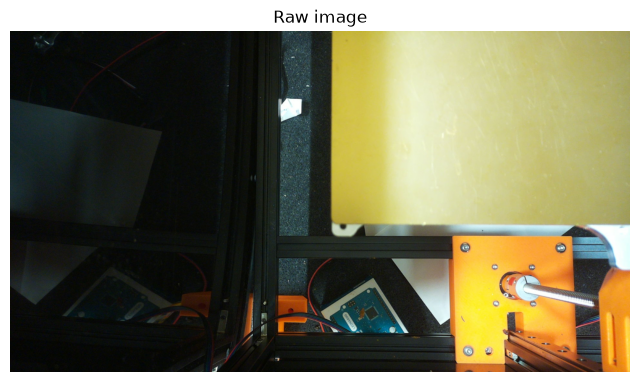

In [3]:
img = cam.get_image()
show(img, "Raw image")

#### Open the camera tab (octoprint) to perform autofocus

(np.float64(-0.5), np.float64(1919.5), np.float64(1055.5), np.float64(-0.5))

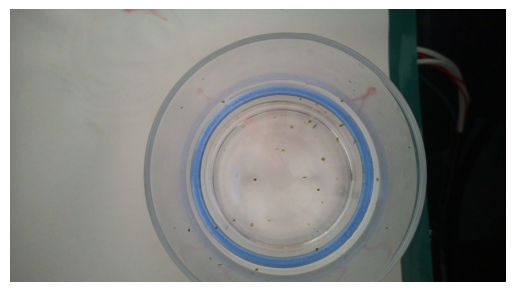

In [4]:
plt.imshow(img)
plt.axis("off")

## 3 — Float Detection

Centre (px): (1052, 645)
Radius (px): 356.3122863769531
Cardinal points:
 [[ 695.74524  645.78613]
 [1052.0575   289.47385]
 [1408.3698   645.78613]
 [1052.0575  1002.0984 ]]


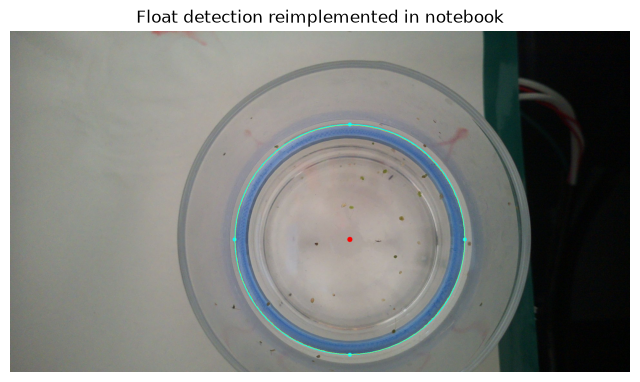

In [5]:
threshold_blue = 150
min_area_px = 250
min_circularity = 0.7

float_det = get_float_points(
    img,
    threshold_blue=threshold_blue,
    min_area_px=min_area_px,
    min_circularity=min_circularity,
 )
print("Centre (px):", float_det.center_px)
print("Radius (px):", float_det.radius_px)
print("Cardinal points:\n", float_det.points)

vis = img.copy()
for pt in float_det.points:
    cv2.circle(vis, (int(pt[0]), int(pt[1])), 6, (0, 255, 255), -1)
cv2.circle(vis, float_det.center_px, int(float_det.radius_px), (0, 255, 255), 2)
cv2.drawContours(vis, [float_det.contour], -1, (255, 255, 0), 1)
cv2.circle(vis, float_det.center_px, 8, (255, 0, 0), -1)
show(vis, "Float detection reimplemented in notebook")

## 4 — Segmentation (ExG only)

ExG contours: 28


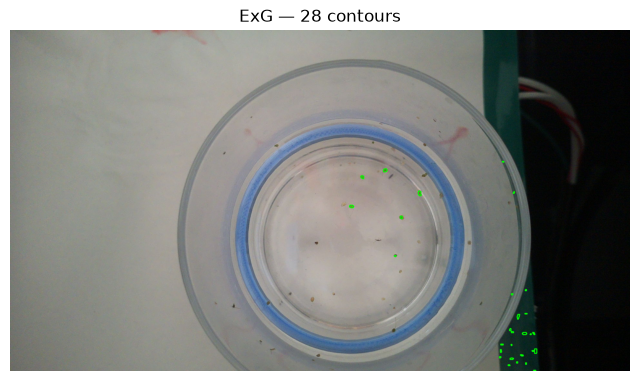

In [6]:
min_area_px = 10
max_area_px = 500
min_circularity = 0.5
threshold_green = 160

# ExG segmentation only
contours_exg = get_img_contour(
    img,
    min_area_px=min_area_px,
    max_area_px=max_area_px,
    min_circularity=min_circularity,
    threshold_green=threshold_green,
 )

print(f"ExG contours: {len(contours_exg)}")

vis_exg = img.copy()
cv2.drawContours(vis_exg, contours_exg, -1, (0, 255, 0), 2)

plt.figure(figsize=(8, 6))
plt.imshow(vis_exg)
plt.title(f"ExG — {len(contours_exg)} contours")
plt.axis("off")
plt.show()

## 5 — Isolated duckweed detection (ExG only)

ExG target pixel: (1192, 699)
ExG contours inside float: 6
marge_insertion_px=142.52, marge_prise_px=28.50


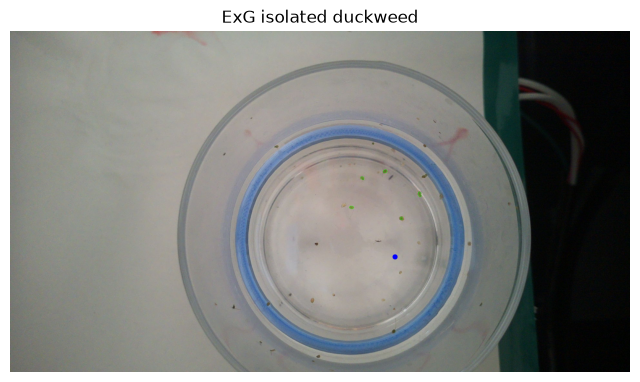

In [7]:
float_radius_mm = 37.5
float_width_mm = 5.0
insertion_margin_mm = 15.0
target_margin_mm = 3.0
tool_radius_mm = 1.27
max_distance_ratio = 0.75

conversion_factor = float_radius_mm / float_det.radius_px
marge_insertion_px = insertion_margin_mm / conversion_factor
marge_prise_px = target_margin_mm / conversion_factor
tool_radius_px = max(1, int(tool_radius_mm / conversion_factor))
float_width_px = max(1, int(float_width_mm / conversion_factor))

target_px, contours_in_float = detect_isolated_duckweed(
    img,
    float_points=float_det.points,
    valid_contours=contours_exg,
    max_distance_ratio=max_distance_ratio,
    float_contour=float_det.contour,
    return_filtered_contours=True,
    marge=marge_prise_px,
 )

print("ExG target pixel:", target_px)
print(f"ExG contours inside float: {len(contours_in_float)}")
print(f"marge_insertion_px={marge_insertion_px:.2f}, marge_prise_px={marge_prise_px:.2f}")

vis = img.copy()
cv2.drawContours(vis, contours_in_float, -1, (0, 255, 0), 1)
if target_px:
    cv2.circle(vis, target_px, 8, (0, 0, 255), -1)

plt.figure(figsize=(8, 6))
plt.imshow(vis)
plt.title("ExG isolated duckweed")
plt.axis("off")
plt.show()

## 6 — Pose estimation (float depth via PnP)

In [8]:
tvec = estimate_float_pose(cam, float_det.points, float_radius_mm=37.5)
water_level = tvec[2] - 1.5
print(f"Float 3D (camera frame): X={tvec[0]:.1f}  Y={tvec[1]:.1f}  Z={tvec[2]:.1f} mm")
print(f"Water level (Z): {water_level:.1f} mm")

Float 3D (camera frame): X=9.5  Y=11.5  Z=154.5 mm
Water level (Z): 153.0 mm


## 7 — 3D localization of the duckweed

In [9]:
if target_px is None:
    print("No target detected — cannot localise.")
else:
    duckweed_3d = get_lens_position(cam, target_px, water_level)
    print(f"Duckweed 3D (camera frame): X={duckweed_3d[0]:.2f}  Y={duckweed_3d[1]:.2f}  Z={duckweed_3d[2]:.2f} mm")

    x_machine = X_DEPART + duckweed_3d[0]
    y_machine = Y_DEPART + duckweed_3d[1]
    z_machine = Z_DEPART + duckweed_3d[2]
    print(f"Machine frame target: X={x_machine:.2f}  Y={y_machine:.2f}  Z={z_machine:.2f}")

Duckweed 3D (camera frame): X=24.09  Y=16.64  Z=152.99 mm
Machine frame target: X=244.09  Y=43.36  Z=47.01


## 8 — Insertion point planning
Build an obstacle mask inside the float, then compute a safe insertion point using the new insertion-point ingredient.

In [10]:
max_offset_px = 50

h, w = img.shape[:2]
obstacle_mask = np.zeros((h, w), dtype=np.uint8)
roi_mask = np.zeros((h, w), dtype=np.uint8)

roi_radius = max(1, int(float_det.radius_px) - float_width_px)
cv2.circle(roi_mask, float_det.center_px, roi_radius, 255, -1)

# Obstacles: outside ROI + all detected duckweed contours except target
outside_roi = cv2.bitwise_not(roi_mask)
obstacle_mask = np.zeros((h, w), dtype=np.uint8)
for cnt in contours_exg:
    if target_px is None or cv2.pointPolygonTest(cnt, target_px, False) < 0:
        cv2.drawContours(obstacle_mask, [cnt], -1, 255, thickness=cv2.FILLED)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (tool_radius_px * 2, tool_radius_px * 2))
obstacle_mask = cv2.dilate(obstacle_mask, kernel)
obstacle_mask = cv2.bitwise_or(obstacle_mask, outside_roi)

if target_px is None:
    insertion_px = None
    masked_for_insertion = obstacle_mask.copy()
    print("No target detected — insertion point not computed.")
else:
    insertion_px, masked_for_insertion = get_insertion_point_2(
        obstacle_mask=obstacle_mask,
        duckweed_goal=target_px,
        marge=marge_insertion_px,
        max_offset_px=max_offset_px,
    )
    print("Insertion point (bounded):", insertion_px)

Insertion point (bounded): (1174, 533)


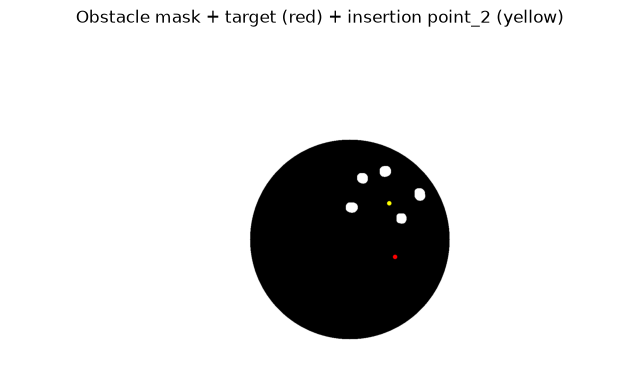

In [11]:
vis = cv2.cvtColor(obstacle_mask, cv2.COLOR_GRAY2BGR)
if target_px is not None:
    cv2.circle(vis, target_px, 7, (255, 0, 0), -1)
if insertion_px is not None:
    cv2.circle(vis, insertion_px, 7, (255, 255, 0), -1)

show(vis, "Obstacle mask + target (red) + insertion point_2 (yellow)")

## 9 — RRT path planning
Plan a collision-free 2D path from the insertion point to the target duckweed using the new RRT ingredient.

Raw path nodes: 12
Smoothed path nodes: 2


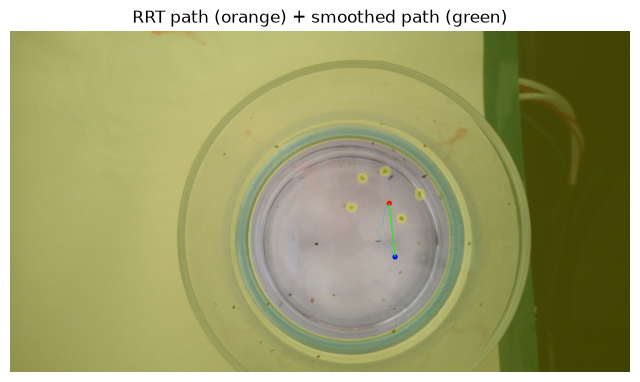

In [12]:
marge_rrt = marge_prise_px
step_size = 20
max_iter = 3000
goal_sample_rate = 0.1

if target_px is None or insertion_px is None:
    print("Missing target/insertion point — RRT skipped.")
    path_2d = None
    path_smooth = None
else:
    path_2d = rrt_path_planning(
        start_2d=insertion_px,
        goal_2d=target_px,
        obstacle_mask=obstacle_mask,
        roi_mask=roi_mask,
        marge=marge_rrt,
        step_size=step_size,
        max_iter=max_iter,
        goal_sample_rate=goal_sample_rate,
    )
    path_smooth = smooth_path(path_2d, obstacle_mask) if path_2d else None
    print("Raw path nodes:", 0 if path_2d is None else len(path_2d))
    print("Smoothed path nodes:", 0 if path_smooth is None else len(path_smooth))

vis = img.copy()

# Obstacles in yellow
overlay = vis.copy()
overlay[obstacle_mask > 0] = (255, 255, 0)
vis = cv2.addWeighted(vis, 0.75, overlay, 0.25, 0)

if target_px is not None:
    cv2.circle(vis, target_px, 8, (0, 0, 255), -1)
if insertion_px is not None:
    cv2.circle(vis, insertion_px, 8, (255, 0, 0), -1)

if path_2d:
    for p0, p1 in zip(path_2d[:-1], path_2d[1:]):
        cv2.line(vis, p0, p1, (0, 165, 255), 1)  # orange raw path
if path_smooth:
    for p0, p1 in zip(path_smooth[:-1], path_smooth[1:]):
        cv2.line(vis, p0, p1, (0, 255, 0), 2)  # green smoothed path

show(vis, "RRT path (orange) + smoothed path (green)")

In [ ]:
insertion_px